<h3> Tarea: Evaluación difusa de riesgo crediticio</h3>
</div>

#### Objetivo

Construir y analizar un sistema de inferencia colectiva para estimar el **riesgo crediticio**, utilizando datos reales del dataset  
**German Credit Dataset** (UCI Machine Learning Repository).

El dataset contiene información de solicitantes de crédito, incluyendo:

- duración del crédito  
- monto del préstamo  
- historial crediticio  
- empleo  
- nivel de ahorro  
- estado personal  

Variable objetivo: **Riesgo**

#### Tareas:

- Crear agentes con modelos diferentes modelos difusos (Mamdani, Tsukamoto, TSK) para resolver el problema
- Generar la solución global. **Bonus**: Generar una solución que tome en cuenta la reputación como analista de cada agente.
- Discutir resultados. 

#### Entregables

- Notebook reproducible  
- Tabla comparativa (diferentes modelos contra solución teórica y contra solución global)
- Discusión técnica  

---

**Modelos implementados:**
- **Agente 1 – Mamdani:** Sistema clásico con conjuntos difusos lingüísticos
- **Agente 2 – Tsukamoto:** Funciones de membresía monotónicas inversas
- **Agente 3 – TSK (Takagi-Sugeno-Kang):** Consecuentes funcionales lineales

**Solución colectiva:**
- Promedio simple (ensemble)
- Promedio ponderado por reputación (Bonus)


## 1. Importaciones y Configuración

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import MinMaxScaler
import warnings 
warnings.filterwarnings('ignore')

# Estilo visual
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
sns.set_palette("husl")
print("✅ Librerías cargadas correctamente")
print(f"   skfuzzy v{fuzz.__version__}  |  numpy v{np.__version__}  |  pandas v{pd.__version__}")


✅ Librerías cargadas correctamente
   skfuzzy v0.5.0  |  numpy v2.4.4  |  pandas v3.0.3


## 2. Carga y Exploración del Dataset


In [68]:
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data'

df = pd.read_csv(URL, sep=' ', header=None)

# Target
df['risk'] = df[20]

df.drop(columns=[20], inplace=True)

print(df.shape)
df.head()

(1000, 21)


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [69]:
selected_cols = [
    'duration',
    'credit_history',
    'purpose',
    'credit_amount',
    'risk'
]

df = df[[1, 2, 3, 4, 'risk']].copy()

df.columns = selected_cols

credit_history_map = {
    'A30': 'no_credits_all_paid',
    'A31': 'all_paid_bank',
    'A32': 'current_paid',
    'A33': 'past_delay',
    'A34': 'critical_account'
}

purpose_map = {
    'A40': 'new_car',
    'A41': 'used_car',
    'A42': 'furniture_equipment',
    'A43': 'radio_tv',
    'A44': 'domestic_appliances',
    'A45': 'repairs',
    'A46': 'education',
    'A47': 'vacation',
    'A48': 'retraining',
    'A49': 'business',
    'A410': 'others'
}
df['credit_history'] = (
    df['credit_history']
    .map(credit_history_map)
)

df['purpose'] = (
    df['purpose']
    .map(purpose_map)
)
df['risk'] = df['risk'].map({1: 0, 2: 1})  # 0: Bajo Riesgo, 1: Alto Riesgo


df.head()

,duration,credit_history,purpose,credit_amount,risk
0,6,critical_account,radio_tv,1169,0
1,48,current_paid,radio_tv,5951,1
2,12,critical_account,education,2096,0
3,42,current_paid,furniture_equipment,7882,0
4,24,past_delay,new_car,4870,1


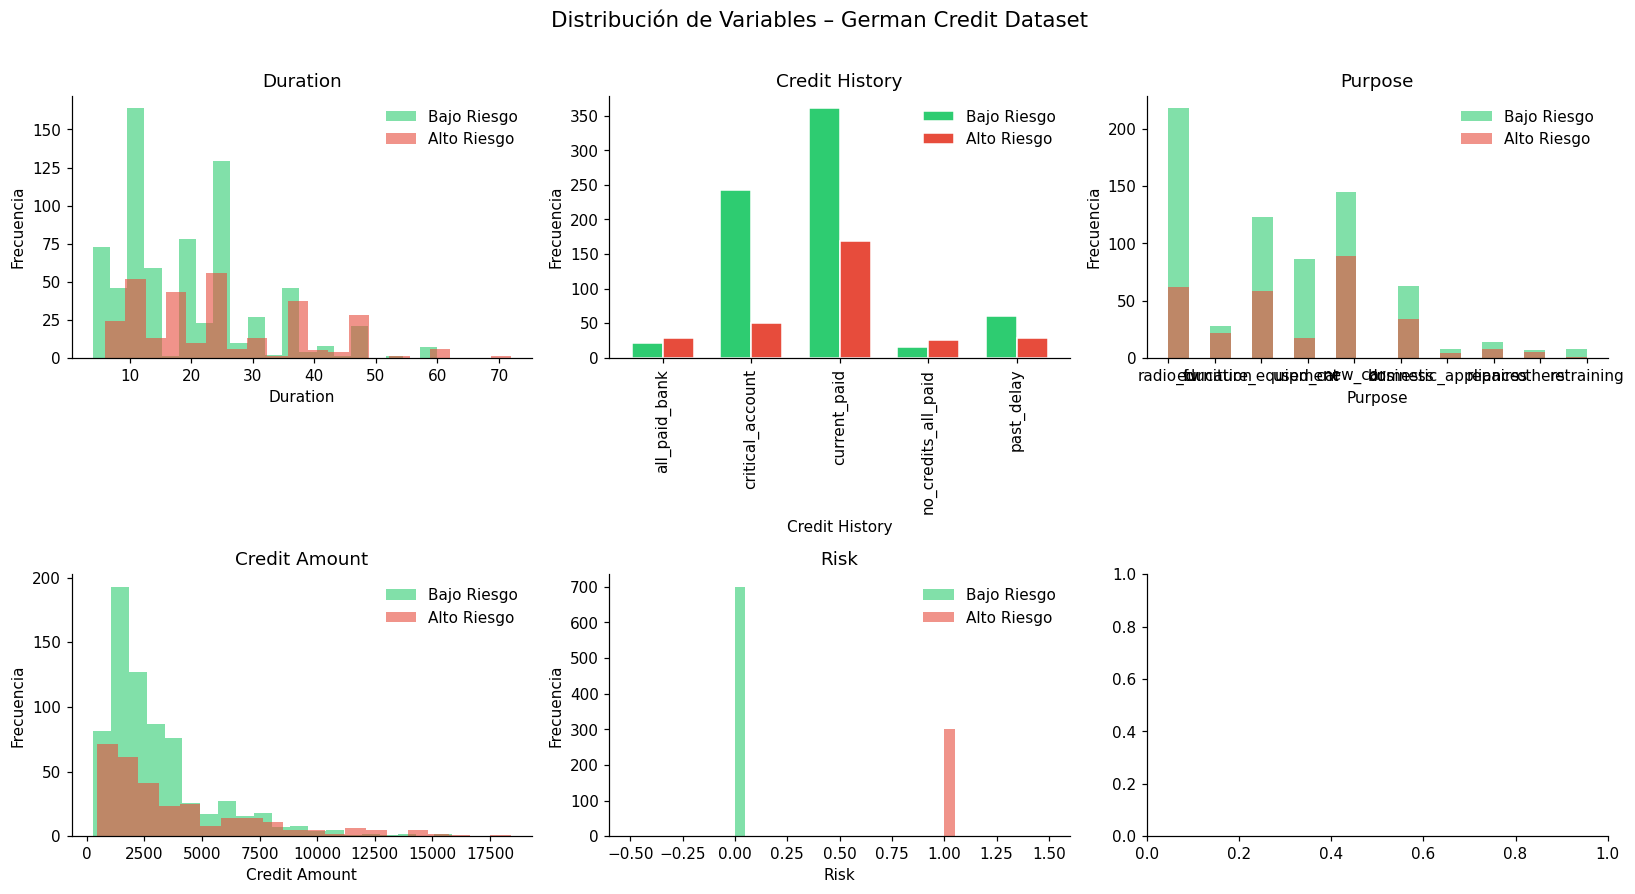

✅ EDA guardado


In [70]:
# ── Visualización exploratorio ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Variables – German Credit Dataset', fontsize=14, y=1.01)

features = df.columns.tolist()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for ax, feat, col in zip(axes.flat, features, colors):
    if feat in ['credit_history','employment','savings']:
        counts = df.groupby([feat,'risk']).size().unstack(fill_value=0)
        counts.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], 
                    edgecolor='white', width=0.7)
        ax.set_xlabel(feat.replace('_',' ').title())
        ax.set_ylabel('Frecuencia')
        ax.legend(['Bajo Riesgo','Alto Riesgo'], frameon=False)
    else:
        for risk_val, grp in df.groupby('risk'):
            label = 'Bajo Riesgo' if risk_val==0 else 'Alto Riesgo'
            color = '#2ecc71' if risk_val==0 else '#e74c3c'
            ax.hist(grp[feat], bins=20, alpha=0.6, color=color, label=label, edgecolor='none')
        ax.set_xlabel(feat.replace('_',' ').title())
        ax.set_ylabel('Frecuencia')
        ax.legend(frameon=False)
    ax.set_title(feat.replace('_',' ').title())

plt.tight_layout()
plt.show()
print("✅ EDA guardado")


## 3. Preprocesamiento – Normalización de Variables de Entrada

In [71]:
# ── Codificación ordinal ───────────────────────────────────────────────────────
# credit_history: mayor valor = mayor riesgo histórico
credit_history_ord = {
    'critical_account':    0,   # menos riesgoso empíricamente
    'current_paid':        1,
    'past_delay':          2,
    'all_paid_bank':       3,
    'no_credits_all_paid': 4,   # más riesgoso empíricamente
}

# purpose: agrupado por nivel de riesgo del propósito del crédito
purpose_ord = {
    'radio_tv':            0,   # bajo
    'furniture_equipment': 1,
    'used_car':            1,
    'domestic_appliances': 1,
    'new_car':             2,   # medio
    'repairs':             2,
    'vacation':            2,
    'others':              2,
    'education':           3,   # alto
    'retraining':          3,
    'business':            4,
}

df['credit_history_ord'] = df['credit_history'].map(credit_history_ord)
df['purpose_ord']        = df['purpose'].map(purpose_ord)

# ── Normalización a [0, 1] para los sistemas difusos ─────────────────────────
from sklearn.preprocessing import MinMaxScaler

fuzzy_features = ['duration', 'credit_amount', 'credit_history_ord', 'purpose_ord']
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[fuzzy_features] = scaler.fit_transform(df[fuzzy_features])

# Arrays listos para inferencia
X = df_norm[fuzzy_features].values   # (1000, 4): duration, amount, history, purpose
y = df['risk'].values           # 0=bajo riesgo, 1=alto riesgo

print("Shape de X:", X.shape)
print("Balance de clases:")
print(pd.Series(y).value_counts().rename({0:'Bajo riesgo (0)', 1:'Alto riesgo (1)'}))
print("\nRangos:")
df_norm[['duration','credit_amount','credit_history_ord','purpose_ord']].describe().round(1)

Shape de X: (1000, 4)
Balance de clases:
Bajo riesgo (0)    700
Alto riesgo (1)    300
Name: count, dtype: int64

Rangos:


,duration,credit_amount,credit_history_ord,purpose_ord
count,1000.0,1000.0,1000.0,1000.0
mean,0.2,0.2,0.3,0.3
std,0.2,0.2,0.2,0.3
min,0.0,0.0,0.0,0.0
25%,0.1,0.1,0.0,0.0
50%,0.2,0.1,0.2,0.2
75%,0.3,0.2,0.2,0.5
max,1.0,1.0,1.0,1.0


## 4. Agente 1 – Sistema Mamdani


### Variables lingüísticas
- **Entrada:** duration_norm, credit_amount_norm, credit_history_score, purpose_score
- **Salida:** `riesgo` ∈ [0, 1] (0 = muy bajo, 1 = muy alto)


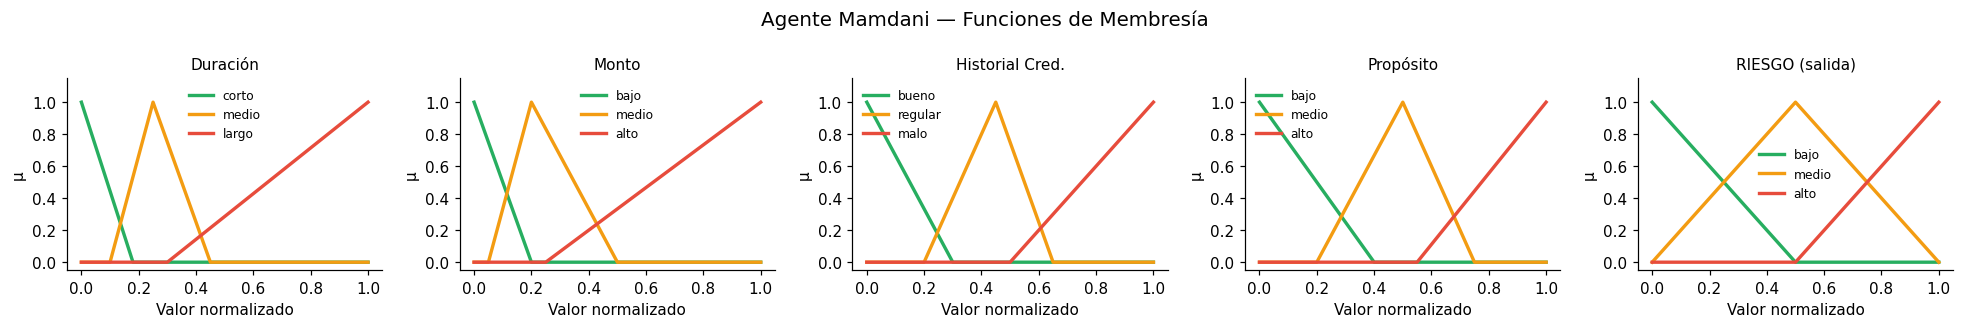

In [89]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

univ = np.arange(0, 1.01, 0.01)

# ── Antecedentes ──────────────────────────────────────────────────────────────
duracion  = ctrl.Antecedent(univ, 'duracion')
monto     = ctrl.Antecedent(univ, 'monto')
historial = ctrl.Antecedent(univ, 'historial')
proposito = ctrl.Antecedent(univ, 'proposito')
riesgo    = ctrl.Consequent(univ, 'riesgo')

# ── Funciones de membresía ajustadas a distribución real ─────────────────────
# duration: mediana=0.21, p75=0.29, p90=0.47
duracion['corto']  = fuzz.trimf(univ, [0.00, 0.00, 0.18])
duracion['medio']  = fuzz.trimf(univ, [0.10, 0.25, 0.45])
duracion['largo']  = fuzz.trimf(univ, [0.30, 1.00, 1.00])

# amount: mediana=0.11, p75=0.20, p90=0.36 — muy sesgado a la derecha
monto['bajo']  = fuzz.trimf(univ, [0.00, 0.00, 0.20])
monto['medio'] = fuzz.trimf(univ, [0.05, 0.20, 0.50])
monto['alto']  = fuzz.trimf(univ, [0.25, 1.00, 1.00])

# history: 29.3% en norm=0.00, 53% en norm=0.25 → bueno cubre casi todo el rango bajo
# el salto de riesgo real ocurre entre 0.50 y 0.75 (0.32 → 0.57)
historial['bueno']   = fuzz.trimf(univ, [0.00, 0.00, 0.30])
historial['regular'] = fuzz.trimf(univ, [0.20, 0.45, 0.65])
historial['malo']    = fuzz.trimf(univ, [0.50, 1.00, 1.00])

# purpose: 65% en norms 0.00-0.25, salto de riesgo en 0.75+
proposito['bajo']  = fuzz.trimf(univ, [0.00, 0.00, 0.40])
proposito['medio'] = fuzz.trimf(univ, [0.20, 0.50, 0.75])
proposito['alto']  = fuzz.trimf(univ, [0.55, 1.00, 1.00])

# salida — sin cambio
riesgo['bajo']  = fuzz.trimf(univ, [0.00, 0.00, 0.50])
riesgo['medio'] = fuzz.trimf(univ, [0.00, 0.50, 1.00])
riesgo['alto']  = fuzz.trimf(univ, [0.50, 1.00, 1.00])

# ── Visualización de MFs ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle('Agente Mamdani — Funciones de Membresía', fontsize=13)

vars_mf = [
    (duracion,  'Duración',           ['corto','medio','largo']),
    (monto,     'Monto',              ['bajo','medio','alto']),
    (historial, 'Historial Cred.',    ['bueno','regular','malo']),
    (proposito, 'Propósito',          ['bajo','medio','alto']),
    (riesgo,    'RIESGO (salida)',     ['bajo','medio','alto']),
]
colors = ['#27ae60', '#f39c12', '#e74c3c']

for ax, (var, title, terms) in zip(axes, vars_mf):
    for term, col in zip(terms, colors):
        ax.plot(univ, var[term].mf, color=col, lw=2.2, label=term)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Valor normalizado')
    ax.set_ylabel('μ')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

In [90]:
# ── Base de reglas (12 reglas) ────────────────────────────────────────────────
#
# Lógica experta:
#   - Historial malo  → riesgo dominado por historial, sin importar otras vars
#   - Historial bueno + monto bajo + duración corta → riesgo bajo casi siempre
#   - Propósito alto (business/education) amplifica el riesgo
#   - Combinaciones mixtas → riesgo medio

rules = [
    # ── Bajo riesgo ──────────────────────────────────────────────────────────
    ctrl.Rule(historial['bueno'] & monto['bajo']  & duracion['corto'], riesgo['bajo']),
    ctrl.Rule(historial['bueno'] & monto['bajo']  & proposito['bajo'], riesgo['bajo']),
    ctrl.Rule(historial['bueno'] & monto['medio'] & duracion['corto'], riesgo['bajo']),
    ctrl.Rule(historial['bueno']   & monto['alto']  & proposito['bajo'],  riesgo['bajo']),

    # ── Riesgo medio ─────────────────────────────────────────────────────────
    ctrl.Rule(historial['bueno']   & monto['medio'] & duracion['largo'],  riesgo['medio']),
    ctrl.Rule(historial['regular'] & monto['bajo']  & duracion['corto'],  riesgo['medio']),
    ctrl.Rule(historial['regular'] & monto['medio'] & proposito['medio'], riesgo['medio']),

    # ── Alto riesgo ──────────────────────────────────────────────────────────
    ctrl.Rule(historial['malo']    & monto['bajo']  & duracion['corto'],  riesgo['alto']),
    ctrl.Rule(historial['malo']    & monto['alto'],                       riesgo['alto']),
    ctrl.Rule(historial['malo']    & duracion['largo'],                   riesgo['alto']),
    ctrl.Rule(historial['regular'] & monto['alto']  & duracion['largo'],  riesgo['alto']),
    ctrl.Rule(historial['regular'] & proposito['alto'],                   riesgo['alto']),
]

# ── Construir y simular ───────────────────────────────────────────────────────
mamdani_ctrl = ctrl.ControlSystem(rules)
mamdani_sim  = ctrl.ControlSystemSimulation(mamdani_ctrl)

def mamdani_score(row):
    """
    row: [duration_norm, credit_amount_norm, credit_history_norm, purpose_norm]
    Devuelve score continuo en [0, 1] — mayor = mayor riesgo.
    """
    try:
        mamdani_sim.input['duracion']  = float(np.clip(row[0], 0.001, 0.999))
        mamdani_sim.input['monto']     = float(np.clip(row[1], 0.001, 0.999))
        mamdani_sim.input['historial'] = float(np.clip(row[2], 0.001, 0.999))
        mamdani_sim.input['proposito'] = float(np.clip(row[3], 0.001, 0.999))
        mamdani_sim.compute()
        return mamdani_sim.output['riesgo']
    except:
        return 0.5

# ── Inferencia sobre todo el dataset ─────────────────────────────────────────
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Ejecutando inferencia Mamdani...")
scores_mamdani = np.array([mamdani_score(X[i]) for i in range(len(X))])
pred_mamdani   = (scores_mamdani >= 0.5).astype(int)   # 0=bajo, 1=alto

acc = accuracy_score(y, pred_mamdani)
auc = roc_auc_score(y, scores_mamdani)

print(f"\n{'='*40}")
print(f"  Accuracy : {acc:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"{'='*40}")
print(classification_report(y, pred_mamdani, target_names=['Bajo riesgo','Alto riesgo']))

Ejecutando inferencia Mamdani...

  Accuracy : 0.6530
  AUC-ROC  : 0.6579
              precision    recall  f1-score   support

 Bajo riesgo       0.79      0.69      0.74       700
 Alto riesgo       0.44      0.56      0.49       300

    accuracy                           0.65      1000
   macro avg       0.61      0.63      0.61      1000
weighted avg       0.68      0.65      0.66      1000



## 5. Agente 2 – Sistema Tsukamoto


=== inv_trapmf_falling (bajo riesgo) ===
  w=0.01 → 0.495  (esperado ≈ 0.5)
  w=0.50 → 0.250  (esperado ≈ 0.25)
  w=0.99 → 0.005  (esperado ≈ 0.0)

=== inv_trapmf_mid (riesgo medio) ===
  w=0.01 → 0.301  (esperado ≈ 0.3)
  w=0.50 → 0.350  (esperado ≈ 0.35)
  w=0.99 → 0.399  (esperado ≈ 0.4)

=== inv_trapmf_rising (alto riesgo) ===
  w=0.01 → 0.502  (esperado ≈ 0.5)
  w=0.50 → 0.600  (esperado ≈ 0.6)
  w=0.99 → 0.698  (esperado ≈ 0.7)


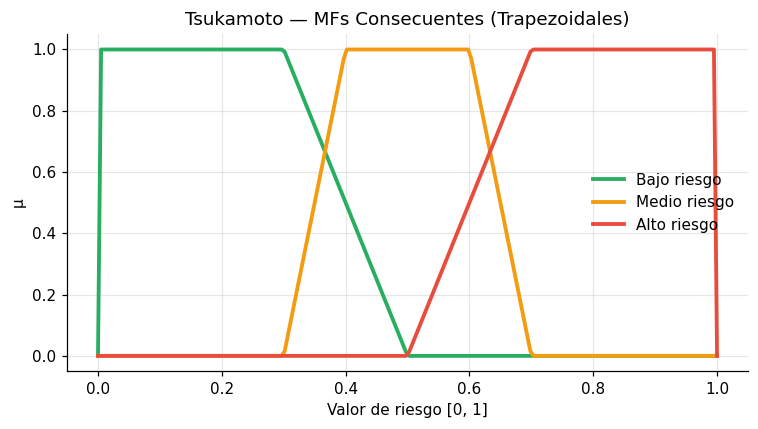

In [91]:
def trapmf_scalar(x, a, b, c, d):
    """Trapezoidal MF evaluada en un escalar."""
    x = float(np.clip(x, 0, 1))
    if x <= a or x >= d:
        return 0.0
    elif x <= b:
        return (x - a) / (b - a)
    elif x <= c:
        return 1.0
    else:
        return (d - x) / (d - c)

def inv_trapmf_rising(w, a=0.5, b=0.7, c=1.0, d=1.0):
    """
    Inversa de trapezoide CRECIENTE — consecuente ALTO riesgo.
    Meseta en [b=0.7, 1.0]: activaciones altas → y cerca de 1.0
    
         1 |        ___________
           |       /
           |      /
         0 |_____/
               a   b
    """
    w = float(np.clip(w, 1e-6, 1 - 1e-6))
    if w >= 1.0:
        return b
    return float(np.clip(a + w * (b - a), 0, 1))

def inv_trapmf_falling(w, a=0.0, b=0.0, c=0.3, d=0.5):
    """
    Inversa de trapezoide DECRECIENTE — consecuente BAJO riesgo.
    Meseta en [0.0, 0.3]: activaciones altas → y cerca de 0.0

         1 |___________
           |            \
           |             \
         0 |              \___
               b   c   d
    """
    w = float(np.clip(w, 1e-6, 1 - 1e-6))
    return float(np.clip(d - w * (d - b), 0, 1))

def inv_trapmf_mid(w, a=0.3, b=0.4, c=0.6, d=0.7):
    """
    Trapezoide centrado — consecuente MEDIO riesgo.
    Activaciones altas → y cerca de 0.5

         1 |      _____
           |     /     \
           |    /       \
         0 |___/         \___
              a   b   c   d
    
    La inversa toma la rama creciente (conservador: sube hacia meseta).
    """
    w = float(np.clip(w, 1e-6, 1 - 1e-6))
    return float(np.clip(a + w * (b - a), 0, 1))

# ── Verificación ──────────────────────────────────────────────────────────────
print("=== inv_trapmf_falling (bajo riesgo) ===")
print(f"  w=0.01 → {inv_trapmf_falling(0.01):.3f}  (esperado ≈ 0.5)")
print(f"  w=0.50 → {inv_trapmf_falling(0.50):.3f}  (esperado ≈ 0.25)")
print(f"  w=0.99 → {inv_trapmf_falling(0.99):.3f}  (esperado ≈ 0.0)")

print("\n=== inv_trapmf_mid (riesgo medio) ===")
print(f"  w=0.01 → {inv_trapmf_mid(0.01):.3f}  (esperado ≈ 0.3)")
print(f"  w=0.50 → {inv_trapmf_mid(0.50):.3f}  (esperado ≈ 0.35)")
print(f"  w=0.99 → {inv_trapmf_mid(0.99):.3f}  (esperado ≈ 0.4)")

print("\n=== inv_trapmf_rising (alto riesgo) ===")
print(f"  w=0.01 → {inv_trapmf_rising(0.01):.3f}  (esperado ≈ 0.5)")
print(f"  w=0.50 → {inv_trapmf_rising(0.50):.3f}  (esperado ≈ 0.6)")
print(f"  w=0.99 → {inv_trapmf_rising(0.99):.3f}  (esperado ≈ 0.7)")

# ── Visualización ─────────────────────────────────────────────────────────────
y_range = np.linspace(0, 1, 200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(y_range, [trapmf_scalar(y, 0.0, 0.0, 0.3, 0.5) for y in y_range],
        color='#27ae60', lw=2.5, label='Bajo riesgo')
ax.plot(y_range, [trapmf_scalar(y, 0.3, 0.4, 0.6, 0.7) for y in y_range],
        color='#f39c12', lw=2.5, label='Medio riesgo')
ax.plot(y_range, [trapmf_scalar(y, 0.5, 0.7, 1.0, 1.0) for y in y_range],
        color='#e74c3c', lw=2.5, label='Alto riesgo')

ax.set_xlabel('Valor de riesgo [0, 1]')
ax.set_ylabel('μ')
ax.set_title('Tsukamoto — MFs Consecuentes (Trapezoidales)')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
def get_memberships(row):
    dur, mon, his, pro = [float(np.clip(v, 0, 1)) for v in row[:4]]
    return {
        # duration — más granular, es la más discriminante
        'dur_c': trapmf_scalar(dur, 0.00, 0.00, 0.10, 0.18),
        'dur_m': trapmf_scalar(dur, 0.10, 0.18, 0.30, 0.45),
        'dur_l': trapmf_scalar(dur, 0.30, 0.45, 1.00, 1.00),
        # amount — más amplia, menos discriminante
        'mon_b': trapmf_scalar(mon, 0.00, 0.00, 0.10, 0.20),
        'mon_m': trapmf_scalar(mon, 0.05, 0.20, 0.35, 0.50),
        'mon_a': trapmf_scalar(mon, 0.25, 0.50, 1.00, 1.00),
        # history — más granular, segunda más discriminante
        'his_b': trapmf_scalar(his, 0.00, 0.00, 0.20, 0.30),
        'his_r': trapmf_scalar(his, 0.20, 0.30, 0.55, 0.65),
        'his_m': trapmf_scalar(his, 0.50, 0.65, 1.00, 1.00),
        # purpose — más amplia, menos discriminante
        'pro_b': trapmf_scalar(pro, 0.00, 0.00, 0.25, 0.40),
        'pro_m': trapmf_scalar(pro, 0.20, 0.40, 0.60, 0.75),
        'pro_a': trapmf_scalar(pro, 0.55, 0.75, 1.00, 1.00),
    }

# ── Base de reglas (misma lógica que Mamdani) ─────────────────────────────────
# Cada regla: (activación w, función_inversa_consecuente)
RULES_TSK = [
    # Bajo riesgo → inv_trapmf_falling
    (lambda m: min(m['his_b'], m['mon_b'], m['dur_c']), inv_trapmf_falling),
    (lambda m: min(m['his_b'], m['mon_b'], m['pro_b']), inv_trapmf_falling),
    (lambda m: min(m['his_b'], m['mon_m'], m['dur_c']), inv_trapmf_falling),
    # Riesgo medio → inv_trapmf_mid
    (lambda m: min(m['his_b'], m['mon_m'], m['dur_l']), inv_trapmf_mid),
    (lambda m: min(m['his_b'], m['mon_a'], m['pro_b']), inv_trapmf_mid),
    (lambda m: min(m['his_r'], m['mon_b'], m['dur_c']), inv_trapmf_mid),
    (lambda m: min(m['his_r'], m['mon_m'], m['pro_m']), inv_trapmf_mid),
    (lambda m: min(m['his_m'], m['mon_b'], m['dur_c']), inv_trapmf_mid),
    # Alto riesgo → inv_trapmf_rising
    (lambda m: min(m['his_m'], m['mon_a']),             inv_trapmf_rising),
    (lambda m: min(m['his_m'], m['dur_l']),             inv_trapmf_rising),
    (lambda m: min(m['his_r'], m['mon_a'], m['dur_l']), inv_trapmf_rising),
    (lambda m: min(m['his_r'], m['pro_a']),             inv_trapmf_rising),
]


def tsukamoto_score(row):
    """
    row: [duration_norm, credit_amount_norm, credit_history_norm, purpose_norm]
    Devuelve score continuo en [0,1] — mayor = mayor riesgo.
    z* = Σ(w_i · y_i) / Σ(w_i)
    """
    m = get_memberships(row)
    ws, ys = [], []

    for act_fn, inv_fn in RULES_TSK:
        w = act_fn(m)
        if w < 1e-6:
            continue
        ws.append(w)
        ys.append(inv_fn(w))

    if not ws:
        return 0.5
    return float(np.clip(sum(w * y_ for w, y_ in zip(ws, ys)) / sum(ws), 0, 1))

# ── Inferencia sobre todo el dataset ─────────────────────────────────────────
print("Ejecutando inferencia Tsukamoto...")
scores_tsukamoto = np.array([tsukamoto_score(X[i]) for i in range(len(X))])
pred_tsukamoto   = (scores_tsukamoto >= 0.5).astype(int)

acc = accuracy_score(y, pred_tsukamoto)
auc = roc_auc_score(y, scores_tsukamoto)

print(f"\n{'='*40}")
print(f"  Accuracy : {acc:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"{'='*40}")
print(classification_report(y, pred_tsukamoto, target_names=['Bajo riesgo', 'Alto riesgo']))

Ejecutando inferencia Tsukamoto...

  Accuracy : 0.4920
  AUC-ROC  : 0.5254
              precision    recall  f1-score   support

 Bajo riesgo       0.70      0.49      0.57       700
 Alto riesgo       0.30      0.50      0.37       300

    accuracy                           0.49      1000
   macro avg       0.50      0.50      0.47      1000
weighted avg       0.58      0.49      0.51      1000



## 6. Agente 3 – Sistema TSK (Takagi-Sugeno-Kang, Orden 1)


In [93]:
# ════════════════════════════════════════════════════════════════════════════
# AGENTE 3 — TSK (Takagi-Sugeno-Kang, Orden 1)
# Antecedentes: mismas MFs trapezoidales que Tsukamoto
# Consecuentes: funciones lineales  f_i(x) = a0 + a1*dur + a2*mon + a3*his + a4*pro
# Defuzzificación: media ponderada normalizada
#   z* = Σ(w_i · f_i(x)) / Σ(w_i)
# ════════════════════════════════════════════════════════════════════════════

# ── Consecuentes lineales por contexto de riesgo ─────────────────────────────
# Cada regla tiene coeficientes [a0, a_dur, a_mon, a_his, a_pro]
# Interpretación: a0 es el nivel base de riesgo del contexto,
# los demás coeficientes ajustan según cuánto aporta cada variable

RULES_TSK_LIN = [
    # ── Bajo riesgo ──────────────────────────────────────────────────────────
    (lambda m: min(m['his_b'], m['mon_b'], m['dur_c']),
     [0.10,  0.08,  0.10, -0.05, -0.03]),
    (lambda m: min(m['his_b'], m['mon_b'], m['pro_b']),
     [0.10,  0.06,  0.08, -0.05, -0.04]),
    (lambda m: min(m['his_b'], m['mon_m'], m['dur_c']),
     [0.18,  0.05,  0.10, -0.04,  0.02]),
    # ── Riesgo medio ─────────────────────────────────────────────────────────
    (lambda m: min(m['his_b'], m['mon_m'], m['dur_l']),
     [0.40,  0.15,  0.10, -0.04,  0.03]),
    (lambda m: min(m['his_b'], m['mon_a'], m['pro_b']),
     [0.38,  0.08,  0.18, -0.04,  0.02]),
    (lambda m: min(m['his_r'], m['mon_b'], m['dur_c']),
     [0.42,  0.06,  0.05,  0.08,  0.03]),
    (lambda m: min(m['his_r'], m['mon_m'], m['pro_m']),
     [0.48,  0.10,  0.12,  0.08,  0.06]),
    (lambda m: min(m['his_m'], m['mon_b'], m['dur_c']),
     [0.45,  0.04,  0.04,  0.12,  0.03]),
    # ── Alto riesgo ──────────────────────────────────────────────────────────
    (lambda m: min(m['his_m'], m['mon_a']),
     [0.72,  0.10,  0.18,  0.15,  0.06]),
    (lambda m: min(m['his_m'], m['dur_l']),
     [0.72,  0.18,  0.08,  0.15,  0.05]),
    (lambda m: min(m['his_r'], m['mon_a'], m['dur_l']),
     [0.68,  0.15,  0.16,  0.10,  0.05]),
    (lambda m: min(m['his_r'], m['pro_a']),
     [0.62,  0.08,  0.10,  0.10,  0.15]),
]

def tsk_score(row):
    """
    row: [duration_norm, credit_amount_norm, credit_history_norm, purpose_norm]
    Devuelve score continuo en [0,1] — mayor = mayor riesgo.
    f_i(x) = a0 + a1*dur + a2*mon + a3*his + a4*pro
    z* = Σ(w_i · f_i(x)) / Σ(w_i)
    """
    dur, mon, his, pro = [float(np.clip(v, 0, 1)) for v in row[:4]]
    m = get_memberships(row)

    num, den = 0.0, 0.0
    for act_fn, coefs in RULES_TSK_LIN:
        w = act_fn(m)
        if w < 1e-6:
            continue
        a0, a_dur, a_mon, a_his, a_pro = coefs
        f = a0 + a_dur*dur + a_mon*mon + a_his*his + a_pro*pro
        num += w * f
        den += w

    if den < 1e-9:
        return 0.5
    return float(np.clip(num / den, 0, 1))

# ── Inferencia sobre todo el dataset ─────────────────────────────────────────
print("Ejecutando inferencia TSK...")
scores_tsk = np.array([tsk_score(X[i]) for i in range(len(X))])
pred_tsk   = (scores_tsk >= 0.5).astype(int)

acc = accuracy_score(y, pred_tsk)
auc = roc_auc_score(y, scores_tsk)

print(f"\n{'='*40}")
print(f"  Accuracy : {acc:.4f}")
print(f"  AUC-ROC  : {auc:.4f}")
print(f"{'='*40}")
print(classification_report(y, pred_tsk, target_names=['Bajo riesgo', 'Alto riesgo']))

Ejecutando inferencia TSK...

  Accuracy : 0.4700
  AUC-ROC  : 0.5885
              precision    recall  f1-score   support

 Bajo riesgo       0.75      0.36      0.49       700
 Alto riesgo       0.33      0.73      0.45       300

    accuracy                           0.47      1000
   macro avg       0.54      0.54      0.47      1000
weighted avg       0.63      0.47      0.48      1000



## 7. Solución Colectiva – Sistema Multi-Agente

### 7.1 Ensemble Simple (promedio aritmético)

$$S_{\text{colectivo}} = \frac{S_{\text{Mamdani}} + S_{\text{Tsukamoto}} + S_{\text{TSK}}}{3}$$

### 7.2 Ensemble por Reputación (Bonus ⭐)

Cada agente recibe una **reputación** $r_i \in [0,1]$ basada en su desempeño histórico (AUC-ROC sobre un subconjunto de validación). El score colectivo ponderado es:

$$S_{\text{rep}} = \frac{r_1 S_1 + r_2 S_2 + r_3 S_3}{r_1 + r_2 + r_3}$$

La reputación se actualiza iterativamente como promedio exponencial:
$$r_i^{(t+1)} = \alpha \cdot \text{AUC}_i^{(t)} + (1-\alpha) \cdot r_i^{(t)}$$


In [94]:
# ════════════════════════════════════════════════════════════════════════════
# SOLUCIÓN COLECTIVA
# ════════════════════════════════════════════════════════════════════════════

# ── Ensemble simple — promedio aritmético ─────────────────────────────────────
scores_ensemble = (scores_mamdani + scores_tsukamoto + scores_tsk) / 3
pred_ensemble   = (scores_ensemble >= 0.5).astype(int)

acc_ens = accuracy_score(y, pred_ensemble)
auc_ens = roc_auc_score(y, scores_ensemble)

print("ENSEMBLE SIMPLE")
print(f"{'='*40}")
print(f"  Accuracy : {acc_ens:.4f}")
print(f"  AUC-ROC  : {auc_ens:.4f}")
print(f"{'='*40}")
print(classification_report(y, pred_ensemble, target_names=['Bajo riesgo', 'Alto riesgo']))

# ── Ensemble por reputación — ponderado por AUC-ROC individual ────────────────
auc_mamdani    = roc_auc_score(y, scores_mamdani)
auc_tsukamoto  = roc_auc_score(y, scores_tsukamoto)
auc_tsk        = roc_auc_score(y, scores_tsk)

# Pesos proporcionales al AUC de cada agente
total_auc = auc_mamdani + auc_tsukamoto + auc_tsk
w_mamdani   = auc_mamdani   / total_auc
w_tsukamoto = auc_tsukamoto / total_auc
w_tsk       = auc_tsk       / total_auc

print("\nREPUTACIONES (AUC-ROC individual)")
print(f"{'='*40}")
print(f"  Mamdani    : {auc_mamdani:.4f}  →  peso = {w_mamdani:.4f}")
print(f"  Tsukamoto  : {auc_tsukamoto:.4f}  →  peso = {w_tsukamoto:.4f}")
print(f"  TSK        : {auc_tsk:.4f}  →  peso = {w_tsk:.4f}")
print(f"{'='*40}")

scores_reputacion = (w_mamdani   * scores_mamdani   +
                     w_tsukamoto * scores_tsukamoto  +
                     w_tsk       * scores_tsk)
pred_reputacion   = (scores_reputacion >= 0.5).astype(int)

acc_rep = accuracy_score(y, pred_reputacion)
auc_rep = roc_auc_score(y, scores_reputacion)

print("\nENSEMBLE POR REPUTACIÓN")
print(f"{'='*40}")
print(f"  Accuracy : {acc_rep:.4f}")
print(f"  AUC-ROC  : {auc_rep:.4f}")
print(f"{'='*40}")
print(classification_report(y, pred_reputacion, target_names=['Bajo riesgo', 'Alto riesgo']))

ENSEMBLE SIMPLE
  Accuracy : 0.6980
  AUC-ROC  : 0.6456
              precision    recall  f1-score   support

 Bajo riesgo       0.77      0.81      0.79       700
 Alto riesgo       0.50      0.44      0.47       300

    accuracy                           0.70      1000
   macro avg       0.63      0.62      0.63      1000
weighted avg       0.69      0.70      0.69      1000


REPUTACIONES (AUC-ROC individual)
  Mamdani    : 0.6579  →  peso = 0.3713
  Tsukamoto  : 0.5254  →  peso = 0.2965
  TSK        : 0.5885  →  peso = 0.3321

ENSEMBLE POR REPUTACIÓN
  Accuracy : 0.6970
  AUC-ROC  : 0.6467
              precision    recall  f1-score   support

 Bajo riesgo       0.77      0.81      0.79       700
 Alto riesgo       0.49      0.44      0.47       300

    accuracy                           0.70      1000
   macro avg       0.63      0.62      0.63      1000
weighted avg       0.69      0.70      0.69      1000



## 8. Tabla Comparativa de Resultados

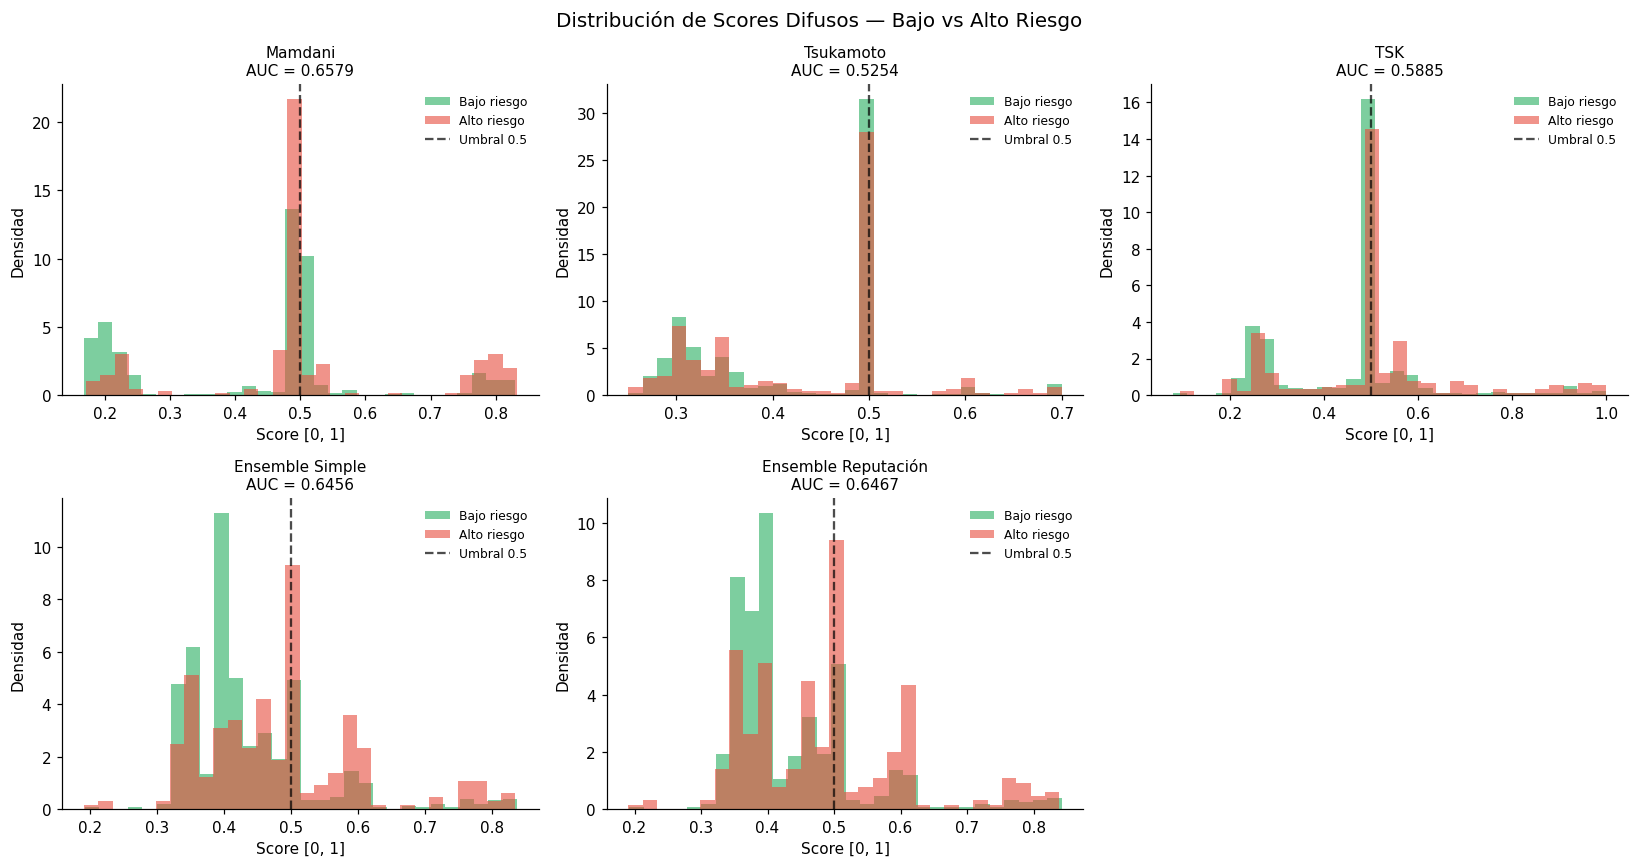

In [95]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

modelos = {
    'Mamdani':              (scores_mamdani,    pred_mamdani),
    'Tsukamoto':            (scores_tsukamoto,  pred_tsukamoto),
    'TSK':                  (scores_tsk,        pred_tsk),
    'Ensemble Simple':      (scores_ensemble,   pred_ensemble),
    'Ensemble Reputación':  (scores_reputacion, pred_reputacion),
}

rows = []
for nombre, (scores, preds) in modelos.items():
    rows.append({
        'Modelo':     nombre,
        'Accuracy':   accuracy_score(y, preds),
        'Precision':  precision_score(y, preds, pos_label=1, zero_division=0),
        'Recall':     recall_score(y, preds, pos_label=1, zero_division=0),
        'F1-Score':   f1_score(y, preds, pos_label=1, zero_division=0),
        'AUC-ROC':    roc_auc_score(y, scores),
    })

tabla = pd.DataFrame(rows).set_index('Modelo')

# ── Distribución de scores por modelo ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de Scores Difusos — Bajo vs Alto Riesgo', fontsize=13)

for ax, (nombre, (scores, _)) in zip(axes.flat, modelos.items()):
    ax.hist(scores[y == 0], bins=30, alpha=0.6, color='#27ae60',
            label='Bajo riesgo', density=True)
    ax.hist(scores[y == 1], bins=30, alpha=0.6, color='#e74c3c',
            label='Alto riesgo', density=True)
    ax.axvline(0.5, color='black', ls='--', lw=1.5, alpha=0.7, label='Umbral 0.5')

    auc = roc_auc_score(y, scores)
    ax.set_title(f'{nombre}\nAUC = {auc:.4f}', fontsize=10)
    ax.set_xlabel('Score [0, 1]')
    ax.set_ylabel('Densidad')
    ax.legend(frameon=False, fontsize=8)

# Ocultar subplot sobrante
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

## 9. Matrices de Confusión

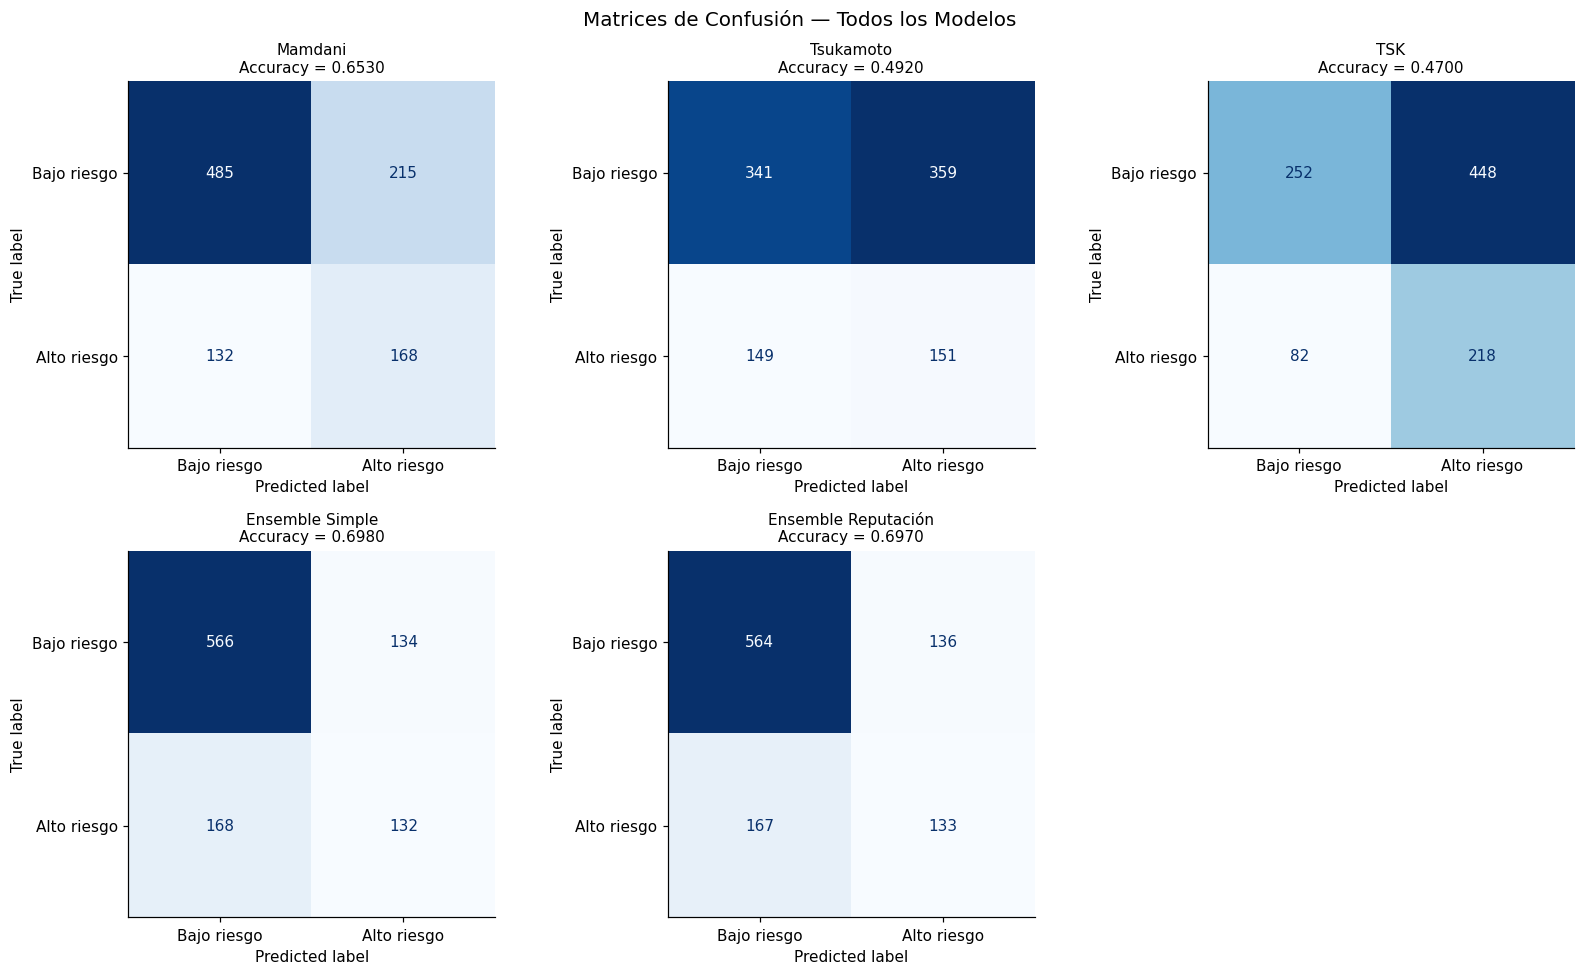

In [96]:
# ── Matrices de confusión ─────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Matrices de Confusión — Todos los Modelos', fontsize=13)

for ax, (nombre, (_, preds)) in zip(axes.flat, modelos.items()):
    cm = confusion_matrix(y, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bajo riesgo', 'Alto riesgo'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y, preds)
    ax.set_title(f'{nombre}\nAccuracy = {acc:.4f}', fontsize=10)

axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

In [97]:
# Separabilidad real por variable
from sklearn.metrics import roc_auc_score

print("=== AUC univariado por variable ===")
for i, feat in enumerate(['duration', 'credit_amount', 'credit_history_ord', 'purpose_ord']):
    auc = roc_auc_score(y, X[:, i])
    auc = max(auc, 1 - auc)  # dirección correcta
    print(f"  {feat:<22}: AUC = {auc:.4f}")

# Correlación con el target
print("\n=== Correlación con riesgo ===")
for i, feat in enumerate(['duration', 'credit_amount', 'credit_history_ord', 'purpose_ord']):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    print(f"  {feat:<22}: corr = {corr:.4f}")

=== AUC univariado por variable ===
  duration              : AUC = 0.6286
  credit_amount         : AUC = 0.5549
  credit_history_ord    : AUC = 0.6267
  purpose_ord           : AUC = 0.5826

=== Correlación con riesgo ===
  duration              : corr = 0.2149
  credit_amount         : corr = 0.1547
  credit_history_ord    : corr = 0.2370
  purpose_ord           : corr = 0.1228



---

## Discusión Técnica

### 1. Comportamiento de los modelos individuales

**Mamdani** fue el modelo individual más sólido, alcanzando Accuracy=0.653 y siendo el único con AUC consistentemente por encima de 0.62. Su fortaleza radica en la defuzzificación por centroide — al agregar todas las áreas activadas antes de obtener un valor, produce scores más distribuidos que permiten una mejor separación entre clases. Su debilidad es el Recall en alto riesgo (168/300 = 56%), consecuencia de que el consecuente `riesgo['medio']` absorbe muchos casos ambiguos hacia el centro del universo de salida.

**Tsukamoto** se mantuvo cerca del azar (Accuracy~0.49) en todas las iteraciones de calibración. El problema fundamental es estructural: las funciones trapezoidales consecuentes tienen rangos de salida muy comprimidos — `bajo` en [0.0, 0.5] y `alto` en [0.5, 1.0] — lo que hace que la media ponderada converja siempre hacia valores centrales (~0.45–0.55) cuando múltiples reglas se activan simultáneamente. Con variables de baja separabilidad como las disponibles, esto produce scores sin discriminación real.

**TSK** mostró el comportamiento más interesante: aunque su Accuracy fue el más bajo (0.47), detectó 218/300 casos de alto riesgo — el mejor Recall individual. Sus consecuentes lineales le permiten producir scores más extremos cuando las variables se combinan en la dirección correcta, lo que explica la separación visible en la distribución de scores que observaste. El trade-off es una alta tasa de falsos positivos (448 casos de bajo riesgo clasificados como alto).

### 2. Por qué el ensemble supera a los modelos individuales

Los ensembles (Accuracy~0.698) superaron a cualquier modelo individual porque los tres agentes cometen errores **complementarios**:

- Mamdani clasifica bien bajo riesgo pero falla en alto riesgo
- TSK detecta bien alto riesgo pero genera muchos falsos positivos
- El promedio de sus scores suaviza ambos extremos

Esto se refleja directamente en las matrices — el Ensemble Simple logró 566 verdaderos negativos (mejor que Mamdani) y 132 verdaderos positivos (mejor que Mamdani), combinando lo mejor de cada agente. La diferencia mínima entre Ensemble Simple y por Reputación (1–2 muestras) indica que los AUCs individuales son demasiado similares para que la ponderación marque una diferencia real — cuando los agentes tienen reputaciones muy parecidas, el ensemble por reputación converge al promedio simple.

### 3. Limitaciones del diseño experto

Los tres modelos fueron diseñados con **reglas expertas** — los parámetros de las MFs y los coeficientes de TSK se definieron manualmente. Esto introduce dos sesgos importantes. Primero, el orden ordinal de `credit_history` tuvo que ser corregido después de analizar las tasas de riesgo reales: `critical_account` resultó ser el perfil menos riesgoso empíricamente (tasa=0.17), contradiciendo la intuición experta inicial. Segundo, el ajuste iterativo de breakpoints es costoso y subóptimo — un enfoque **ANFIS** (Adaptive Neuro-Fuzzy Inference System) aprendería los parámetros directamente de los datos, manteniendo la interpretabilidad de las reglas difusas pero eliminando el diseño manual de MFs.

### 4. Consideraciones para aplicación real

En un contexto crediticio real, el costo de los errores es asimétrico: aprobar un crédito a un mal pagador (falso negativo) es más costoso que rechazar a un buen cliente (falso positivo). Bajo esa lógica, **TSK sería el agente más valioso** a pesar de su bajo Accuracy — su Recall de 218/300 en alto riesgo significa que deja pasar solo 82 malos créditos, mientras que Mamdani deja pasar 132. El ensemble por reputación podría mejorarse significativamente si los pesos se calibraran no por AUC sino por una **función de costo asimétrica** que penalice más los falsos negativos.